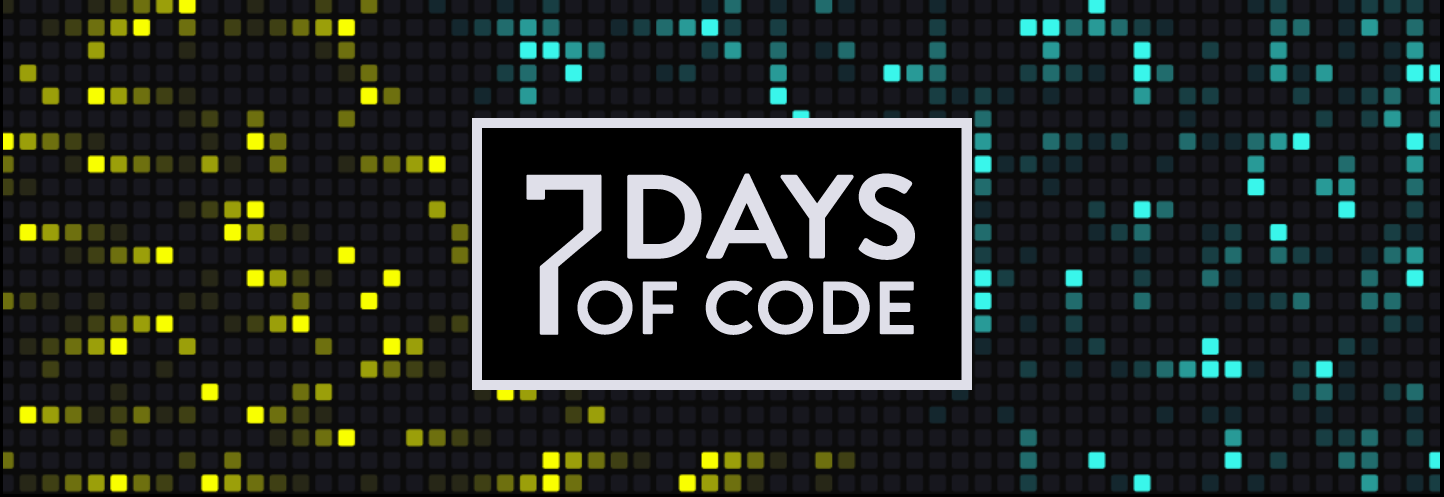

In [164]:
from IPython.display      import Image

Image('img/7daysofcode_logo.png')

# **Cota para Exercício da Atividade Parlamentar dos Senadores - CEAPS**
##  Tratamento e limpeza de dados

In [165]:
!pip install plotly

!pip install nbformat>=4.2.0



### 1. Importando Bibliotecas

In [166]:
#Bibliotecas de Manipulação e Tratamento de dados.
import numpy as np
import pandas as pd



#Bibliotecas de Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


import inflection

#Bibliotecas Auxiliares
from IPython.display      import Image
from IPython.core.display import HTML

import warnings
warnings.filterwarnings( 'ignore' )

#### 1.1 Funções Auxiliares

In [167]:
def jupyter_settings():
    %matplotlib inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [12, 8]
    plt.rcParams['font.size'] = 24
    sns.set_palette("Reds") 
    
    display(HTML( '<style>.container { width:100% !important; }</style>'))
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()

In [168]:
jupyter_settings()

### 2. Carregando os dados

In [169]:
# Leitura dos datasets

dados_2022 = pd.read_csv('dados/despesa_ceaps_2022.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2021 = pd.read_csv('dados/despesa_ceaps_2021.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2020 = pd.read_csv('dados/despesa_ceaps_2020.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2019 = pd.read_csv('dados/despesa_ceaps_2019.csv', encoding = 'cp1252', sep=';', skiprows=1 )
dados_2018 = pd.read_csv('dados/despesa_ceaps_2018.csv', encoding = 'cp1252', sep=';', skiprows=1 )



#Concatenar os dados por ano
df = pd.concat([dados_2022,dados_2021,dados_2020,dados_2019,dados_2018], ignore_index=True)

In [170]:
total_linhas_raw = df.shape[0]
total_linhas_raw 

93825

##### ***Ideia 2: Removendo datas inválidas***

In [171]:
#Foi verificado na base de dados algumas datas inconsistentes, possivelmente por erro de digitação.
# Dados do ano de 2010, 2002, 0202, ou até mesmo com a data 31/02/2022 por exemplo. 
mascara = df['DATA'].str[-2:] == "02"
df.DATA[mascara]

12835    11/02/2002
12839    22/03/2002
12865    16/03/2002
12918    21/06/2002
12925    11/08/2002
14026    02/02/2002
16990    19/02/2002
18930    29/10/0202
43971    05/05/0202
45956    14/03/2002
76364    05/04/2002
Name: DATA, dtype: object

In [172]:
# Usar o método .str para acessar os últimos caracteres da coluna 'DATA' correspondentes ao ano
ano_2022 = df['DATA'].str[-4:] == "2022"
ano_2021 = df['DATA'].str[-4:] == "2021"
ano_2020 = df['DATA'].str[-4:] == "2020"
ano_2019 = df['DATA'].str[-4:] == "2019"
ano_2018 = df['DATA'].str[-4:] == "2018"

# Combinação das condições usando o operador de comparação |
mascara = ano_2022 | ano_2021 | ano_2020 | ano_2019 | ano_2018

# Filtrar o DataFrame usando a máscara com o método .loc
df1 = df.loc[mascara]


In [173]:
dados_excluídos = total_linhas_raw - df1.shape[0]
dados_excluídos

297

### 3. Tratamento e Manipulação dos Dados

#### 3.1 Renomeando Colunas

In [174]:
df1.columns

Index(['ANO', 'MES', 'SENADOR', 'TIPO_DESPESA', 'CNPJ_CPF', 'FORNECEDOR',
       'DOCUMENTO', 'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO',
       'COD_DOCUMENTO'],
      dtype='object')

In [175]:
# Renomeando colunas para o formato SnakeCase (O melhor kk)

cols_old = ['ANO', 'MES', 'SENADOR', 'TIPO_DESPESA', 'CNPJ_CPF', 'FORNECEDOR',
       'DOCUMENTO', 'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO',
       'COD_DOCUMENTO']

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase,cols_old))

df1.columns = cols_new
df1.columns

Index(['ano', 'mes', 'senador', 'tipo_despesa', 'cnpj_cpf', 'fornecedor',
       'documento', 'data', 'detalhamento', 'valor_reembolsado',
       'cod_documento'],
      dtype='object')

#### 3.2 Dimensão dos Dados

In [176]:
# Dimensão do Dataset (Quantidade de Linhas e Colunas)
print(f'Número de Linhas: {df1.shape[0]}\nNúmero de Colunas: {df1.shape[1]}')

Número de Linhas: 93528
Número de Colunas: 11


#### 3.3 Tipo dos dados

In [177]:
# Tipo dos dados do dataset
df1.dtypes

ano                   int64
mes                   int64
senador              object
tipo_despesa         object
cnpj_cpf             object
fornecedor           object
documento            object
data                 object
detalhamento         object
valor_reembolsado    object
cod_documento         int64
dtype: object

In [178]:
df2 = df1.copy()

##### Convertendo tipo de dados

In [179]:
# # senador: Transformar os dados em letras minusculas
df2.senador = df2.senador.str.lower()

# # # tipo_despesa: Tokenização
# df2.tipo_despesa = df2.tipo_despesa.str.split(',')

# # cnpj_cpf: Remover os caracteres '.', '-', e '/' da coluna 'cnpj_cpf', converter para Int64
df2['cnpj_cpf'] = df2['cnpj_cpf'].replace(r'[./-]', '', regex=True)
df2.cnpj_cpf = df2.cnpj_cpf.astype(np.int64)

# # fornecedor: Transformar os dados em letras minusculas
df2.fornecedor = df2.fornecedor.str.lower()

# # data: Transformar object para datetime
df2.data = pd.to_datetime(df2.data, format='%d/%m/%Y')

# # valor_reembolsado: Trocar , por . , converter para float64
df2.valor_reembolsado = df2.valor_reembolsado.str.replace(',','.')
df2.valor_reembolsado = df2.valor_reembolsado.astype(np.float64)


In [180]:
df2.dtypes

ano                           int64
mes                           int64
senador                      object
tipo_despesa                 object
cnpj_cpf                      int64
fornecedor                   object
documento                    object
data                 datetime64[ns]
detalhamento                 object
valor_reembolsado           float64
cod_documento                 int64
dtype: object

#### 3.4 Checagem dos Valores Nulos

In [181]:
# Checagem dos valores nulos em cada coluna
df2.isnull().sum()

ano                      0
mes                      0
senador                  0
tipo_despesa             0
cnpj_cpf                 0
fornecedor               0
documento             3970
data                     0
detalhamento         36263
valor_reembolsado        0
cod_documento            0
dtype: int64

#####  Tratamentos dos dados nulos

In [182]:
# Neste primeiro ciclo, irei substituir os valores nulos por 0
df2.documento.fillna(0, inplace=True)

df2.detalhamento.fillna(0,inplace=True)

In [183]:
#Verificar novamente
df2.isnull().sum()

ano                  0
mes                  0
senador              0
tipo_despesa         0
cnpj_cpf             0
fornecedor           0
documento            0
data                 0
detalhamento         0
valor_reembolsado    0
cod_documento        0
dtype: int64

### 4. Análise Descritiva dos Dados

In [184]:
# Primeiramente vamos separar os dados em variaveis categoricas e variaveis numericas
var_num = df2.select_dtypes(include=['int64','float64'])

var_cat = df2.select_dtypes(exclude=['int64','float64', 'datetime64[ns]'])

##### ***Variáveis Categoricas***

In [185]:
# Medidas de Tendencia Central
ctd1 = var_num.describe()

# Medidas de Dispersão
d1 = pd.DataFrame(var_num.apply(lambda x:x.max()-x.min())).T

d2 = pd.DataFrame(var_num.apply(lambda x:x.skew())).T

d3 = pd.DataFrame(var_num.apply(lambda x: x.kurtosis())).T

# Concatenação das medidas estatisticas
medidas = pd.concat([ctd1,d1,d2,d3]).T.reset_index()

# Renomear colunas
medidas.columns = ['variaveis','count','mean','std','min','25%','median','75%','max','range','skew','kustosis']

medidas

,variaveis,count,mean,std,min,25%,median,75%,max,range,skew,kustosis
0,ano,93528.0,2.019786e+03,1.455523e+00,2.018000e+03,2.018000e+03,2.020000e+03,2.021000e+03,2.022000e+03,4.000000e+00,0.216346,-1.348742
1,mes,93528.0,6.487597e+00,3.352174e+00,1.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01,1.100000e+01,0.039508,-1.183708
2,cnpj_cpf,93528.0,1.938121e+13,1.975949e+13,2.703195e+08,5.481897e+12,1.405830e+13,2.648078e+13,9.859199e+13,9.859172e+13,1.822631,3.400164
3,valor_reembolsado,93528.0,1.315623e+03,3.005453e+03,1.000000e-02,1.500000e+02,3.927200e+02,1.468993e+03,1.200000e+05,1.200000e+05,9.931179,191.515931
4,cod_documento,93528.0,2.139804e+06,3.060239e+04,2.085894e+06,2.112768e+06,2.140152e+06,2.166099e+06,2.198297e+06,1.124030e+05,-0.008491,-1.195978


<Figure size 3000x6000 with 0 Axes>

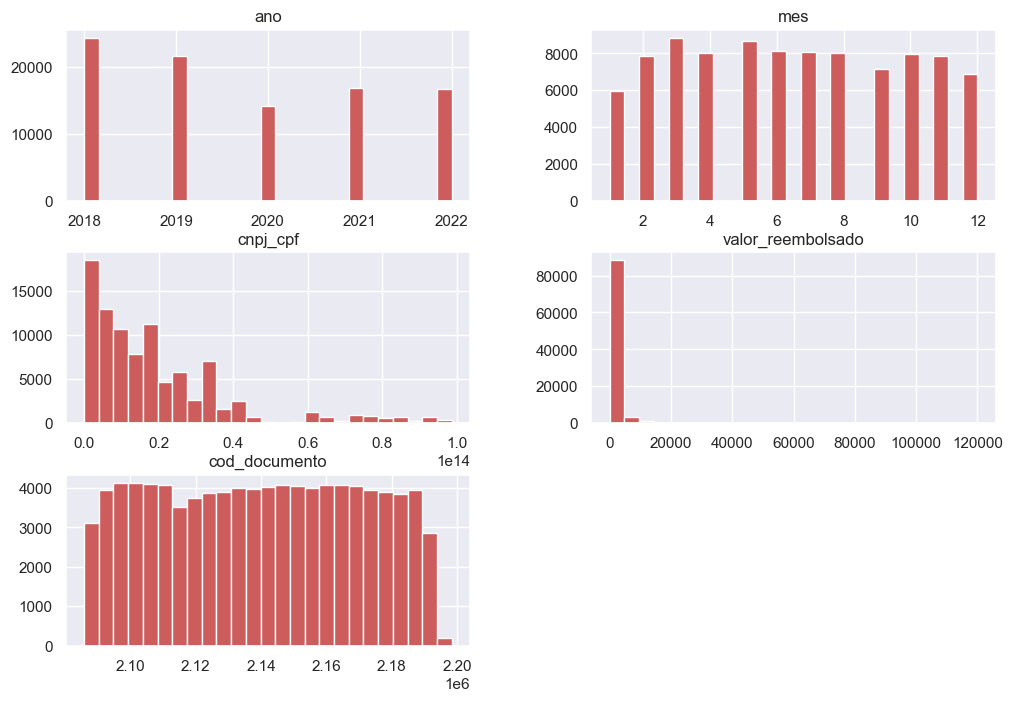

In [186]:
# Gráficos demonstando os dados das variáveis numéricas
plt.figure(figsize = (30,60))
var_num.hist(bins= 25, color= 'indianred');

In [187]:
# plt.figure(figsize=(25,15))
# plt.xticks(rotation=90)
# sns.countplot( x='valor_reembolsado', data=df2, palette = 'Reds')

##### ***Variáveis Categóricas*** 

In [188]:
# Conta a quantidade de valores únicos em cada coluna de um DataFrame com variáveis categóricas.
var_cat.apply(lambda x: x.unique().shape[0])

senador           171
tipo_despesa        7
fornecedor      10989
documento       74418
detalhamento    32139
dtype: int64

<Axes: xlabel='senador', ylabel='count'>

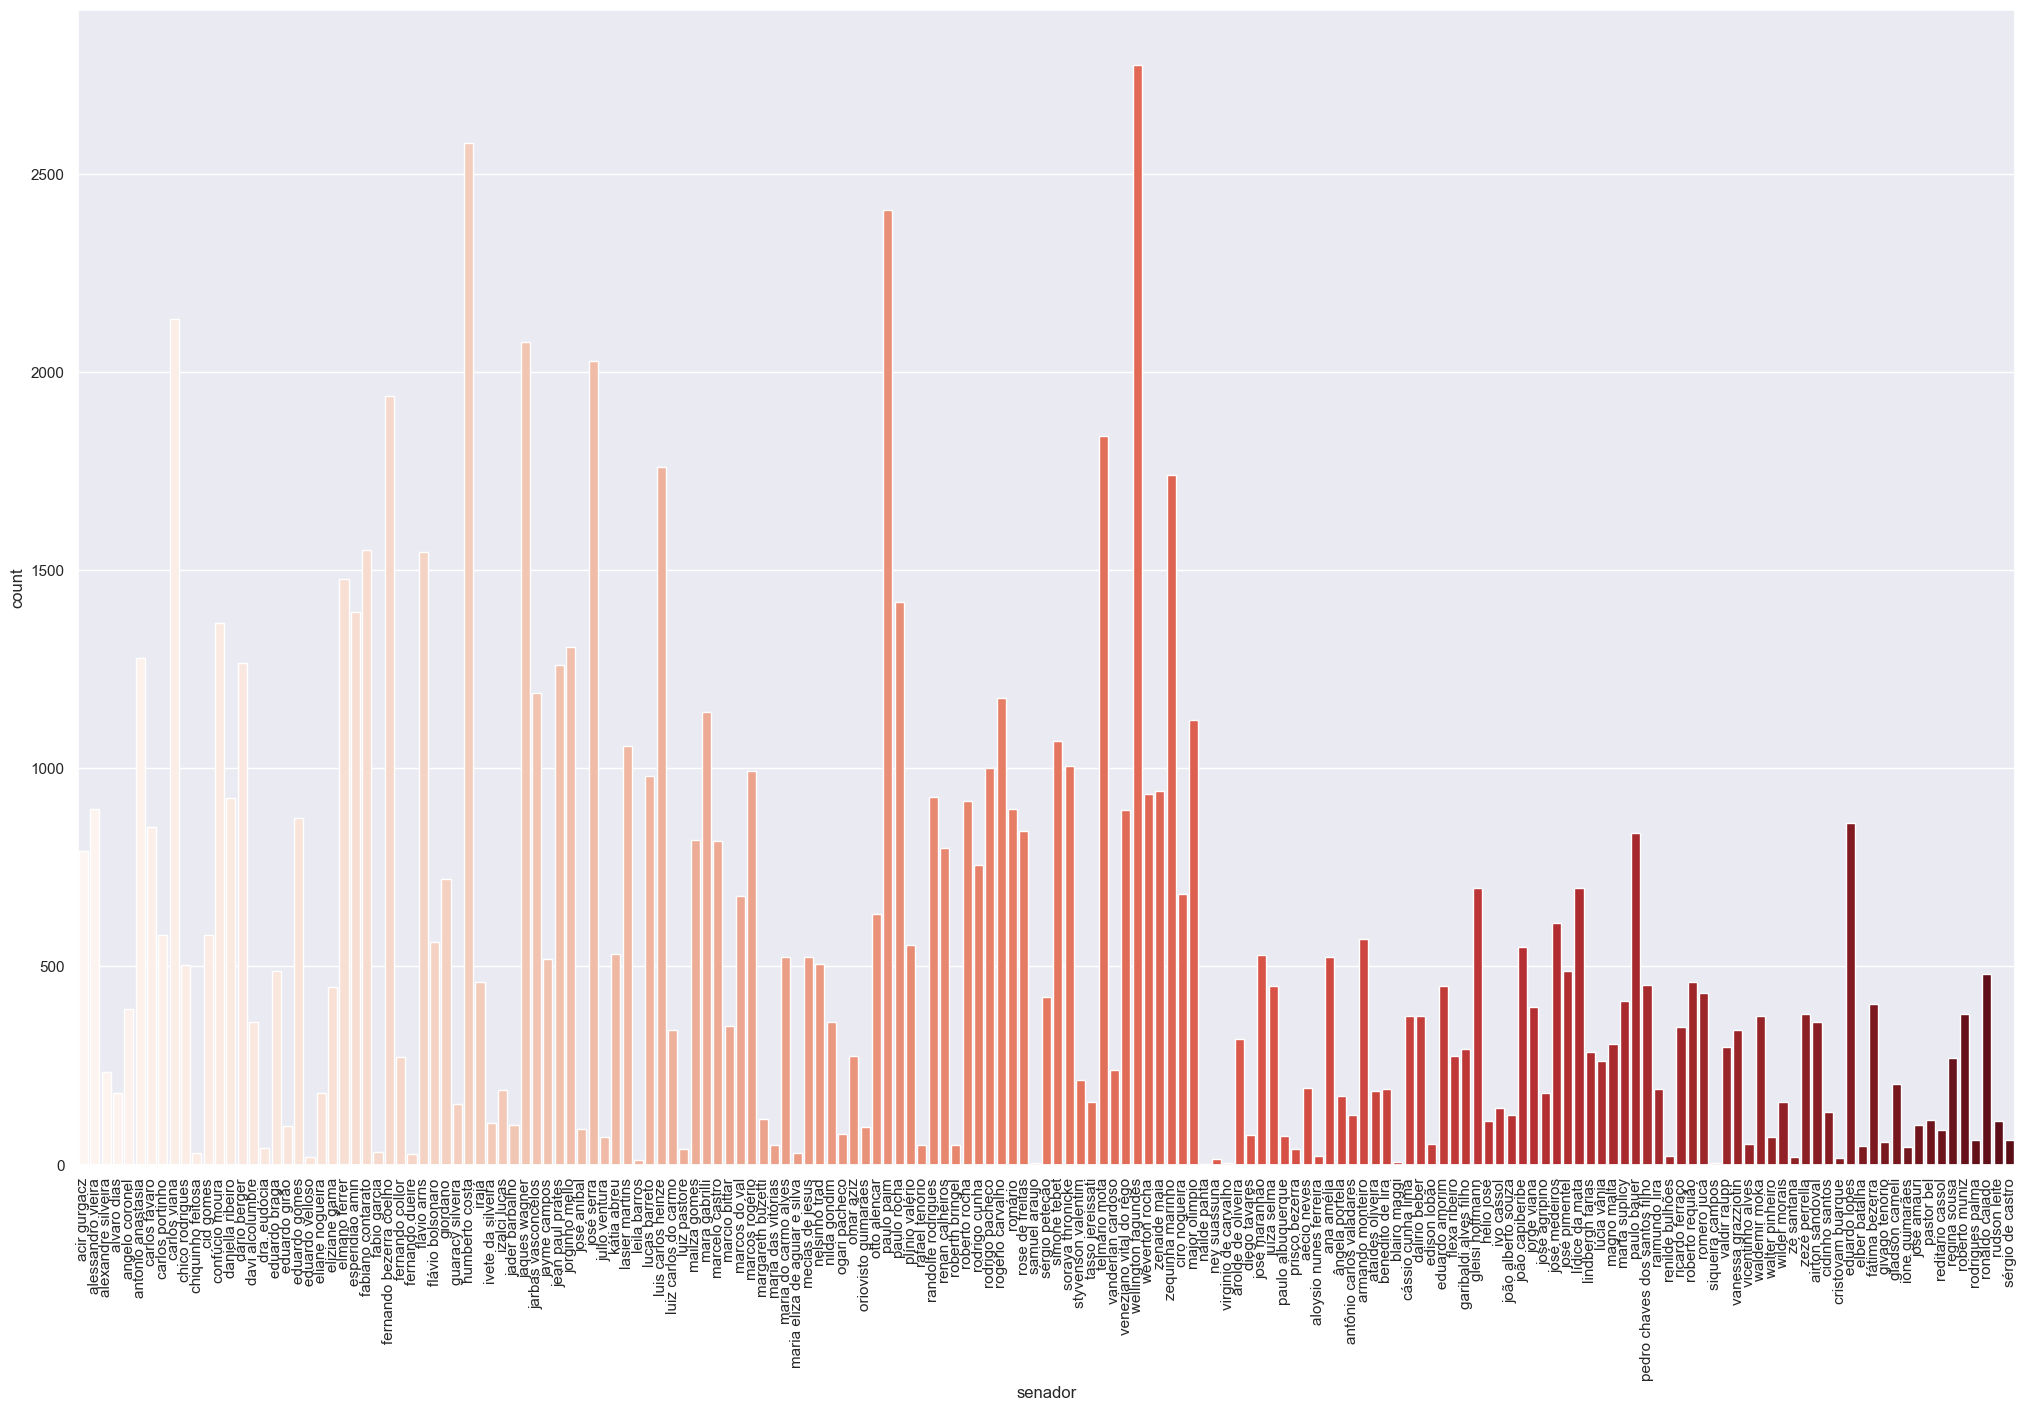

In [189]:
# Plota gráficos de barras da contagem de cada senador que reembolsaram o valor
plt.figure(figsize=(25,15))
plt.xticks(rotation=90)
sns.countplot( x='senador', data=var_cat, palette = 'Reds')

In [190]:
# Dividindo a analise dos senadores em dois pontos, o que mais reembolsam e os que menos reembolsaram
contagem_senadores = df2['senador'].value_counts()
contagem_senadores

senador
wellington fagundes              2776
humberto costa                   2577
paulo paim                       2410
carlos viana                     2135
jaques wagner                    2076
josé serra                       2027
fernando bezerra coelho          1939
telmário mota                    1838
luis carlos heinze               1761
zequinha marinho                 1740
fabiano contarato                1551
flávio arns                      1546
elmano férrer                    1479
paulo rocha                      1421
esperidião amin                  1395
confúcio moura                   1366
jorginho mello                   1307
antonio anastasia                1278
dário berger                     1267
jean paul prates                 1260
jarbas vasconcelos               1191
rogério carvalho                 1177
mara gabrilli                    1143
major olimpio                    1123
simone tebet                     1070
lasier martins                   1056
sora

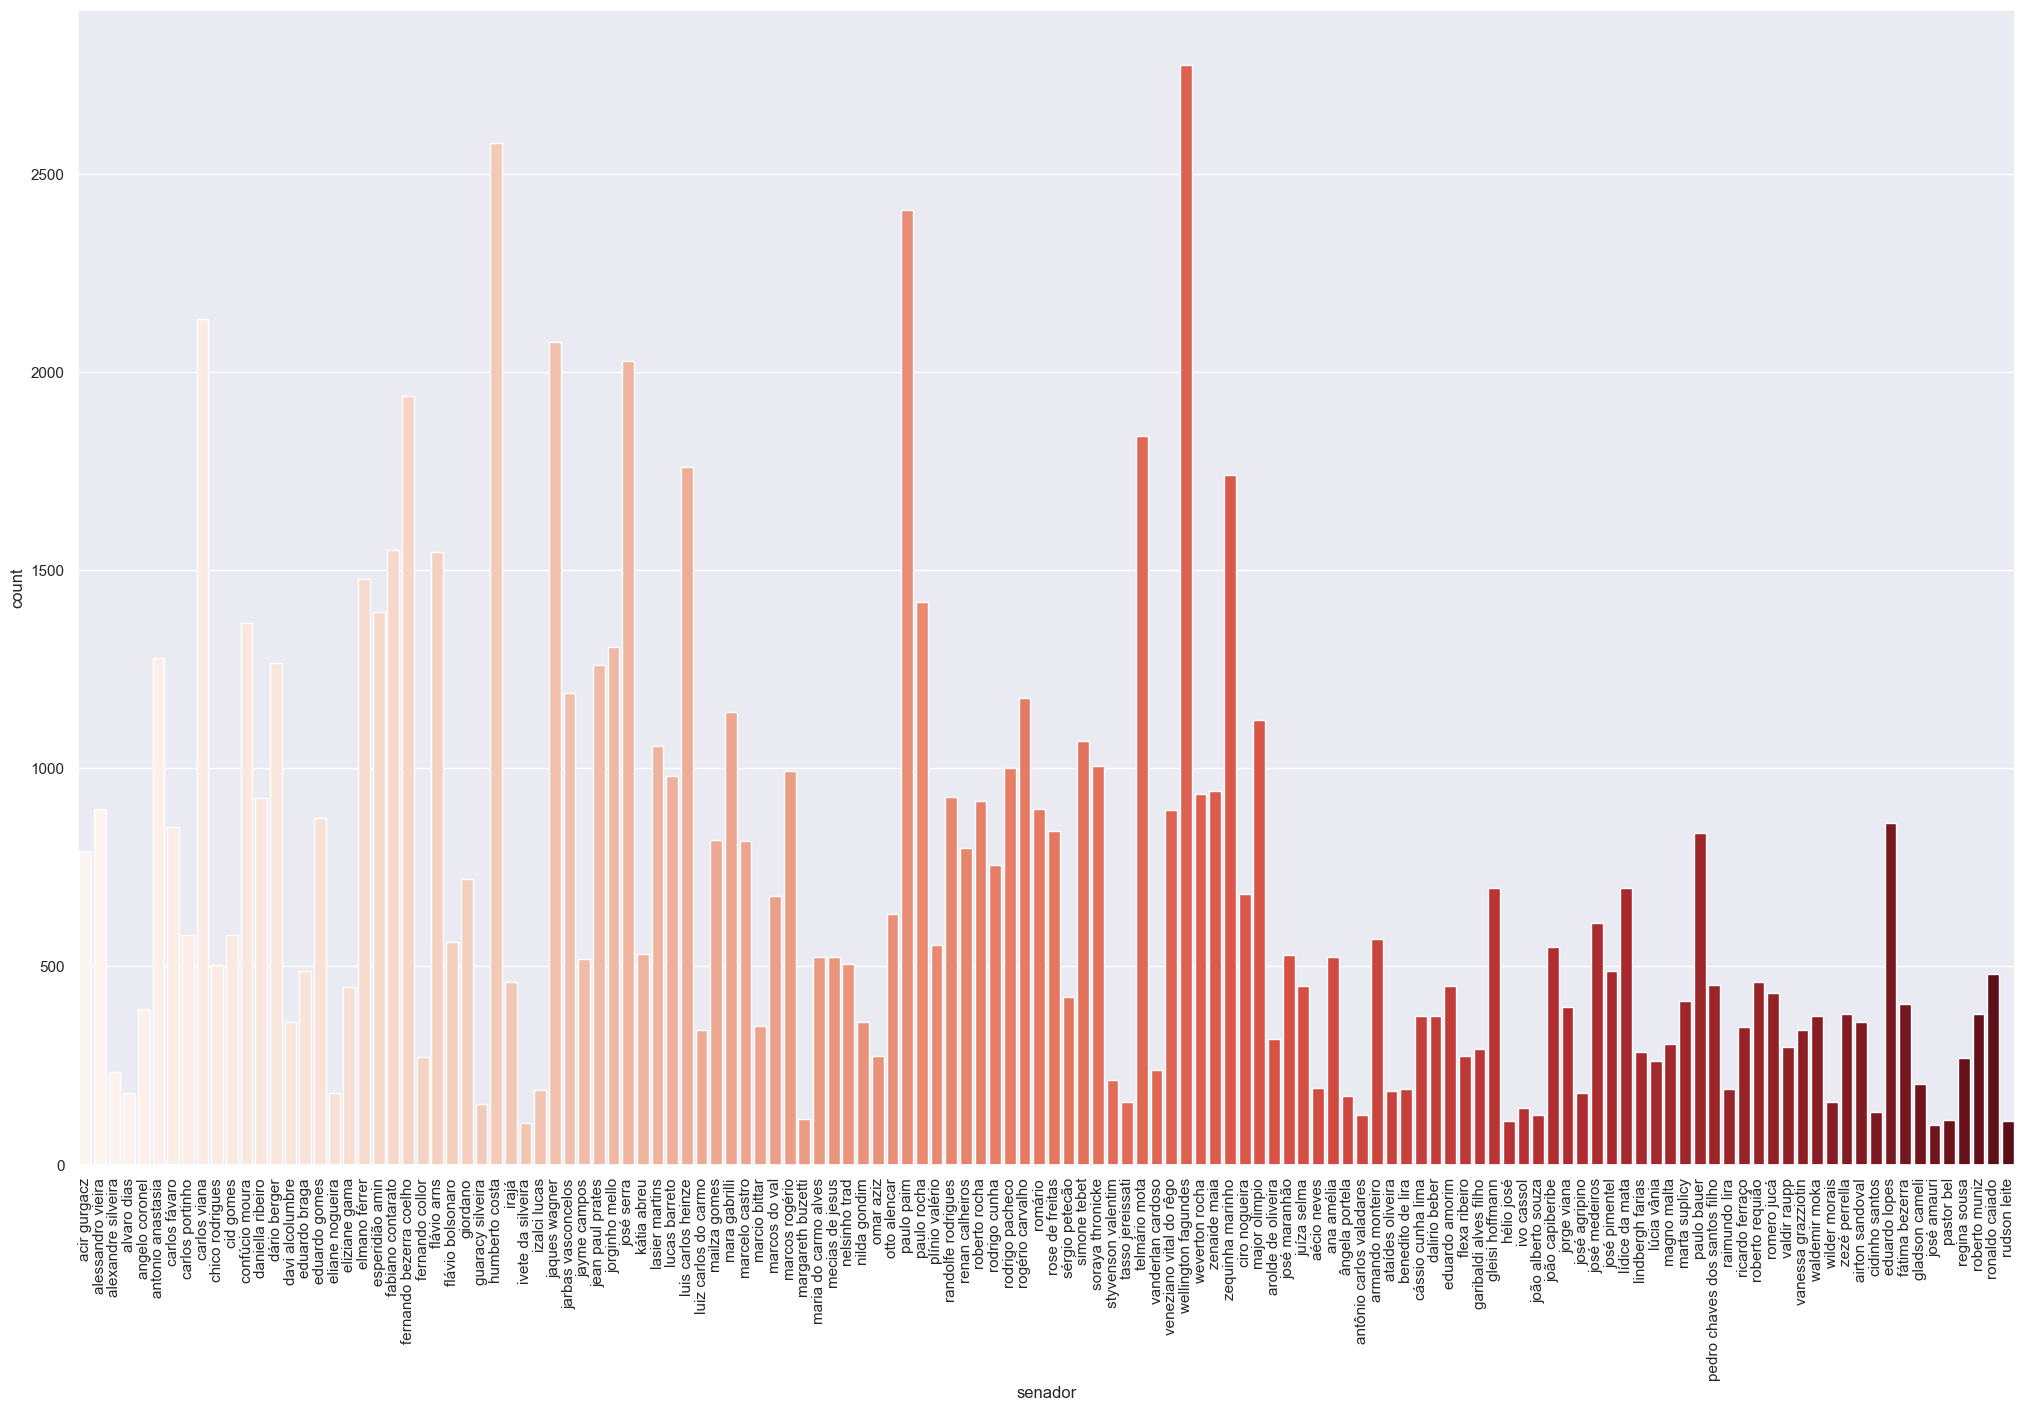

In [191]:
##################### O que mais reembolsaram ##########################
senadores_mais_1000 = contagem_senadores[contagem_senadores > 100].index

df2_filtrado = df2[df2['senador'].isin(senadores_mais_1000)]

# Definir o tamanho da figura
plt.figure(figsize=(25, 15))

# Criar o countplot com Seaborn usando os dados filtrados
sns.countplot(x='senador', data=df2_filtrado, palette='Reds')

# Rotacionar os rótulos do eixo x, se necessário
plt.xticks(rotation=90)

# Exibir o gráfico
plt.show()

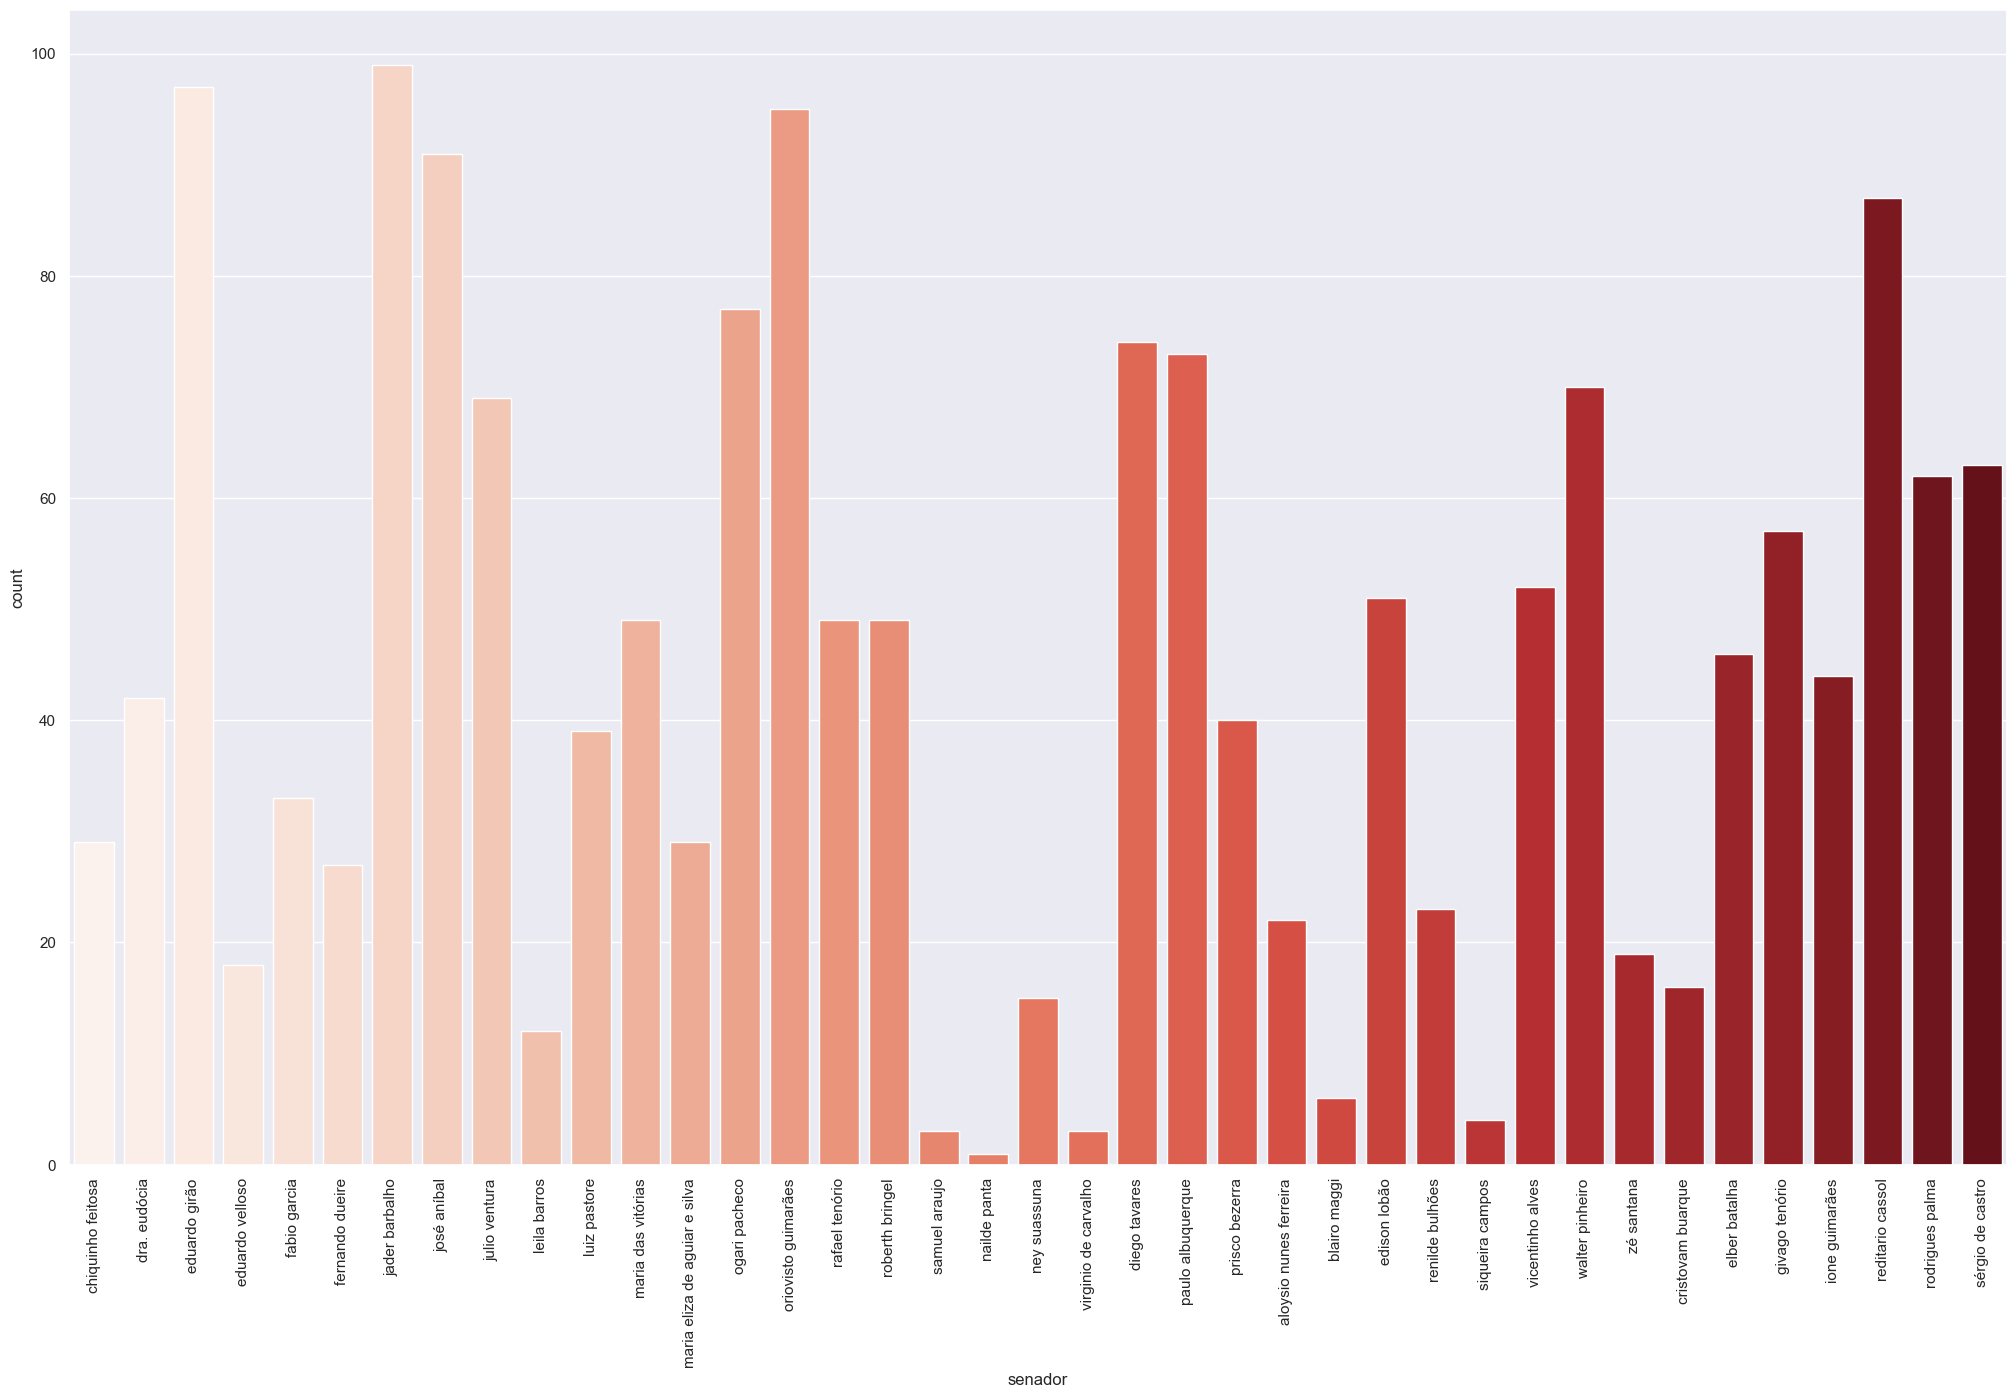

In [192]:
##################### O que menos reembolsaram ##########################
senadores_mais_1000 = contagem_senadores[contagem_senadores < 100].index

df2_filtrado = df2[df2['senador'].isin(senadores_mais_1000)]

# Definir o tamanho da figura
plt.figure(figsize=(25, 15))

# Criar o countplot com Seaborn usando os dados filtrados
sns.countplot(x='senador', data=df2_filtrado, palette='Reds')

# Rotacionar os rótulos do eixo x, se necessário
plt.xticks(rotation=90)

# Exibir o gráfico
plt.show()

<Axes: xlabel='tipo_despesa', ylabel='count'>

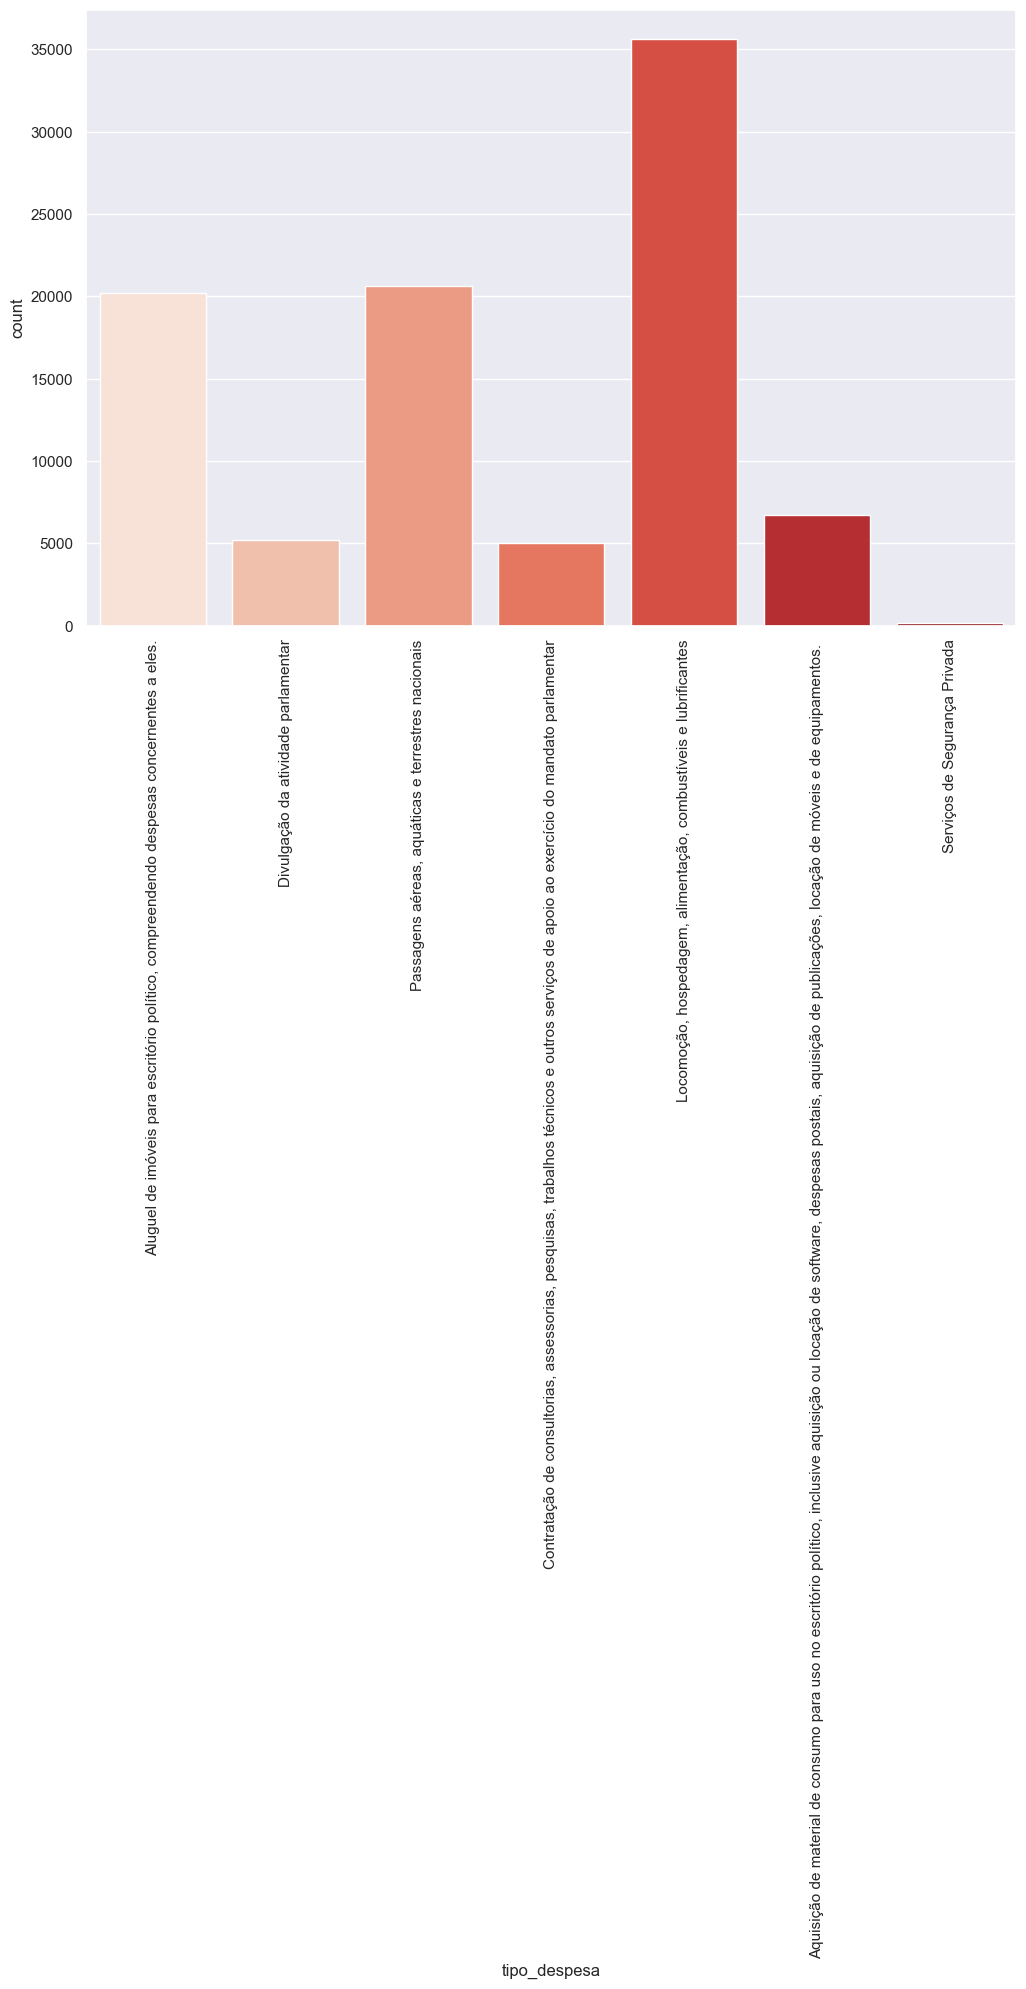

In [193]:
# Plota gráficos de barras da contagem de cada senador que reembolsaram o valor
plt.xticks(rotation=90)
sns.countplot( x=df2.tipo_despesa, data=df2, palette = 'Reds')


# Data Visualization

### 5. Análise Exploratória dos Dados (EDA)

#### 1. Qual foi o senador que mais declarou despesas? 

  - O senador que mais declarou impostos foi o senador Wellington Fagundes
 - O senador que mais reembolsou despesas foi o senador Paulo Rocha

In [197]:
cols = ['senador','valor_reembolsado']

df_aux = df2.loc[:,cols].groupby(['senador']).sum().sort_values('valor_reembolsado', ascending=False).reset_index()

In [198]:
# Criar o gráfico de barras com o Plotly
fig = go.Figure(data=[go.Bar(x=df_aux.senador, y=df_aux.valor_reembolsado)])

# Definir o layout do gráfico, se necessário
fig.update_layout(title='Gráfico de Barras',
                  xaxis_title='Categorias',
                  yaxis_title='Valores')

# Exibir o gráfico
fig.show()

In [194]:
df2_aux = df2.copy()

In [195]:
df2_aux.tipo_despesa =  df2_aux.tipo_despesa.str.split(',')

In [196]:
df2_aux['qtd_despesas'] = df2_aux['tipo_despesa'].apply(len)


In [209]:
col = ['qtd_despesas','senador']

df_despesas = df2_aux.loc[:,col].groupby('senador').sum().sort_values('qtd_despesas',ascending=False).reset_index()

df_despesas.head()

,senador,qtd_despesas
0,wellington fagundes,9525
1,humberto costa,8923
2,paulo paim,8795
3,jaques wagner,7327
4,carlos viana,7226


In [211]:
# Criar o grafico 
fig = go.Figure(data=[go.Bar(x=df_despesas.senador, y=df_despesas.qtd_despesas)])

# Definindo layout do grafico
fig.update_layout(title='Quantidade de despesas por senador',
                    xaxis_title='Senador', yaxis_title='Quantidade de despesas declaradas')

#Plotando gráfico
fig.show()

#### 2. Qual foi o percentual da cota que os senadores gastaram? Teve algum com mais de 90%?

In [199]:
df_aux['percentual'] = ((df_aux['valor_reembolsado'] / df_aux['valor_reembolsado'].sum()) * 100)

df_aux.head()

,senador,valor_reembolsado,percentual
0,paulo rocha,2273841.92,1.847938
1,telmário mota,2264960.24,1.840720
2,eduardo braga,2181124.86,1.772587
3,roberto rocha,2112538.28,1.716847
4,omar aziz,2112469.51,1.716791


In [200]:
# Criar o gráfico de barras com o Plotly
fig = go.Figure(data=[go.Bar(x=df_aux.senador, y=df_aux.percentual)])

# Definir o layout do gráfico, se necessário
fig.update_layout(title='Gráfico de Barras',
                  xaxis_title='Categorias',
                  yaxis_title='Valores')

# Exibir o gráfico
fig.show()

#### 3. Em ano de eleições os senadores gastam mais?

- Os gastos dos senadores se manteram constantes todos os anos, com exceção do ano de 2022 que foi um ano de pandemia do COVID-19

In [201]:
col = ['senador','valor_reembolsado','ano']

df_aux = df2.loc[:,col].groupby(['ano','senador']).sum('valor_reembolsado').sort_values(['ano', 'valor_reembolsado']).reset_index()
df_aux.head()

,ano,senador,valor_reembolsado
0,2018,ione guimarães,11379.91
1,2018,zé santana,23300.67
2,2018,cristovam buarque,32400.00
3,2018,walter pinheiro,32733.67
4,2018,alvaro dias,44037.88


In [202]:
# Criar o gráfico de barras com o Plotly
fig = go.Figure(data=[go.Bar(x=df_aux.ano, y=df_aux.valor_reembolsado)])

# Definir o layout do gráfico, se necessário
fig.update_layout(title='Gráfico de Barras',
                  xaxis_title='Ano',
                  yaxis_title='Valores')

# Exibir o gráfico
fig.show()